# Benchmark Models (HARQ)

In [37]:
import pandas as pd 
import numpy as np
file_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Cleaned Data Sets/RV_total.csv"
df = pd.read_csv(file_path)

# Convert "Date" column to datetime 
df["Date"] = pd.to_datetime(df["Date"], utc=True).dt.tz_convert("Europe/Berlin")
df = df.sort_values("Date").set_index("Date")

df.tail()

,Open,Close,log_open,log_close,r_overnight,RV_intra,RV_overnight,RV_total,RQ,r_daily,log_RV_total,log_RV_intra
Date,,,,,,,,,,,,
2020-08-03 00:00:00+02:00,3186.02,3253.20,8.066528,8.087394,-0.001132,0.000108,0.000001,0.000109,1.898579e-08,0.019734,-9.121878,-9.133686
2020-08-04 00:00:00+02:00,3270.71,3251.94,8.092762,8.087007,0.005368,0.000129,0.000029,0.000158,2.613017e-08,-0.000387,-8.755823,-8.957822
2020-08-05 00:00:00+02:00,3274.81,3267.21,8.094015,8.091692,0.007008,0.000068,0.000049,0.000117,7.450015e-09,0.004685,-9.056151,-9.602531
2020-08-06 00:00:00+02:00,3257.99,3244.07,8.088866,8.084584,-0.002826,0.000109,0.000008,0.000117,1.545187e-08,-0.007108,-9.052878,-9.123543
2020-08-07 00:00:00+02:00,3235.30,3248.01,8.081877,8.085798,-0.002707,0.000089,0.000007,0.000097,3.748493e-08,0.001214,-9.243673,-9.322462


## 1.5 HARQ Model

HARQ augments HAR with a **realized quarticity**-based “noise” interaction term. The idea is that days with high intraday noise/microstructure effects (proxied by $\sqrt{RQ}$) reduce the effective persistence of yesterday's relaized variance. 

**HARQ Model:**
$$
RV_t
= \beta_0
+ \left( \beta_1 + \beta_{1Q} \, RQ_{t-1}^{1/2} \right) RV_{t-1}
+ \beta_2 \, RV_{t-1\mid t-5}
+ \beta_3 \, RV_{t-1\mid t-22}
+ u_t
$$


In [11]:
# =========================
# HARQ Model Construction
# =========================

# Safety procedure
df_harQ = df.copy()
df_harQ = df_harQ.sort_index()

# 1) Base RV series in levels
rv = df_harQ["RV_total"]

# 2) HAR components available at time t
df_harQ["RV_d"] = rv                      # RV_t (known at t)
df_harQ["RV_w"] = rv.rolling(5).mean()    # average RV_{t|t-4}
df_harQ["RV_m"] = rv.rolling(22).mean()   # average RV_{t|t-21}

# 3) Quarticity interaction term (HARQ): sqrt(RQ_t) * RV_t
# Your dataframe already has "RQ" as a daily series.
df_harQ["sqrtRQ"] = np.sqrt(df_harQ["RQ"])
df_harQ["RV_d_x_sqrtRQ"] = df_harQ["RV_d"] * df_harQ["sqrtRQ"]

# 4) Target: next day RV
df_harQ["RV_target"] = rv.shift(-1)

In [13]:
# Drop NA to define usable sample
df_harQ = df_harQ.dropna(subset=["RV_d", "RV_d_x_sqrtRQ", "RV_w", "RV_m", "RV_target"])

print("First usable date:", df_harQ.index.min())
print("Last usable date:", df_harQ.index.max())
print("Number of usable observations:", len(df_harQ))


First usable date: 1998-03-31 00:00:00+02:00
Last usable date: 2020-08-06 00:00:00+02:00
Number of usable observations: 5689


**Deciding on train, validation, and test splits:**
* Train = 1998 - 2012 (Train includes dot-com + GFC → rich volatility regimes) *~60–65% train*
* Validation = 2013 - 2015 (Validation includes Euro crisis aftershocks) *~15% validation*
* Test = 2016 - 2020 (Test includes calm + COVID shock) *~20–25% test*

In [16]:
# Define split dates
train_end = "2012-12-31"
val_end   = "2015-12-31"

df_train = df_harQ.loc[:train_end]
df_val   = df_harQ.loc[train_end:val_end]
df_test  = df_harQ.loc[val_end:]

# Remove boundary overlap (same logic as before)
df_val  = df_val.iloc[1:]
df_test = df_test.iloc[1:]

print("Train observations:", len(df_train))
print("Validation observations:", len(df_val))
print("Test observations:", len(df_test))

print("\nTrain period:", df_train.index.min(), "to", df_train.index.max())
print("Validation period:", df_val.index.min(), "to", df_val.index.max())
print("Test period:", df_test.index.min(), "to", df_test.index.max())

Train observations: 3745
Validation observations: 768
Test observations: 1176

Train period: 1998-03-31 00:00:00+02:00 to 2012-12-31 00:00:00+01:00
Validation period: 2013-01-02 00:00:00+01:00 to 2015-12-31 00:00:00+01:00
Test period: 2016-01-04 00:00:00+01:00 to 2020-08-06 00:00:00+02:00


#### HARQ on Training set

In [20]:
import statsmodels.api as sm

# Regressors and target (training only)
X_train = df_train[["RV_d", "RV_d_x_sqrtRQ", "RV_w", "RV_m"]]
y_train = df_train["RV_target"]

# Add intercept
X_train = sm.add_constant(X_train)

# Estimate OLS
harq_model = sm.OLS(y_train, X_train).fit()
print(harq_model.summary())

                            OLS Regression Results                            
Dep. Variable:              RV_target   R-squared:                       0.596
Model:                            OLS   Adj. R-squared:                  0.595
Method:                 Least Squares   F-statistic:                     1377.
Date:                Thu, 19 Feb 2026   Prob (F-statistic):               0.00
Time:                        14:14:19   Log-Likelihood:                 27279.
No. Observations:                3745   AIC:                        -5.455e+04
Df Residuals:                    3740   BIC:                        -5.452e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          6.708e-06   3.67e-06      1.830

In [22]:
from tqdm import tqdm

df_eval = pd.concat([df_val, df_test])

predictions = []
actuals = []
dates = []

for current_date in tqdm(df_eval.index):

    # Expanding window: all rows strictly before current_date
    df_expanding = df_harQ.loc[:current_date].iloc[:-1]

    X = df_expanding[["RV_d", "RV_d_x_sqrtRQ", "RV_w", "RV_m"]]
    y = df_expanding["RV_target"]

    X = sm.add_constant(X, has_constant="add")
    model = sm.OLS(y, X).fit()

    # Forecast row
    X_fore = df_harQ.loc[[current_date], ["RV_d", "RV_d_x_sqrtRQ", "RV_w", "RV_m"]]
    X_fore = sm.add_constant(X_fore, has_constant="add")
    X_fore = X_fore.reindex(columns=X.columns)

    rv_forecast = float(model.predict(X_fore).iloc[0])
    rv_actual   = float(df_harQ.loc[current_date, "RV_target"])

    predictions.append(rv_forecast)
    actuals.append(rv_actual)
    dates.append(current_date)

df_forecast_harQ = pd.DataFrame({"Forecast": predictions, "Actual": actuals}, index=dates)

print(df_forecast_harQ.head())
print("\nForecast df shape:", df_forecast_harQ.shape)


100%|██████████████████████████████████████| 1944/1944 [00:03<00:00, 584.93it/s]

                           Forecast    Actual
2013-01-02 00:00:00+01:00  0.000136  0.000027
2013-01-03 00:00:00+01:00  0.000046  0.000032
2013-01-04 00:00:00+01:00  0.000050  0.000028
2013-01-07 00:00:00+01:00  0.000047  0.000027
2013-01-08 00:00:00+01:00  0.000048  0.000030

Forecast df shape: (1944, 2)


In [24]:
val_start, val_end = df_val.index.min(), df_val.index.max()
test_start, test_end = df_test.index.min(), df_test.index.max()

df_forecast_val = df_forecast_harQ.loc[val_start:val_end]
df_forecast_test = df_forecast_harQ.loc[test_start:test_end]

mse_val = np.mean((df_forecast_val["Actual"] - df_forecast_val["Forecast"])**2)
mse_test = np.mean((df_forecast_test["Actual"] - df_forecast_test["Forecast"])**2)

print(f"Validation period: {val_start} to {val_end} | n = {len(df_forecast_val)}")
print(f"Test period: {test_start} to {test_end} | n = {len(df_forecast_test)}")

print("\nValidation MSE:", mse_val)
print("Test MSE:", mse_test)

Validation period: 2013-01-02 00:00:00+01:00 to 2015-12-31 00:00:00+01:00 | n = 768
Test period: 2016-01-04 00:00:00+01:00 to 2020-08-06 00:00:00+02:00 | n = 1176

Validation MSE: 1.18587042214482e-08
Test MSE: 2.189973657587814e-08


Test MSE is double the size of Validation MSE, which is economically inuitive as the test period includes the 2018 volatility spike and the 2020 COVID shock. Volatility forecasting models struggle more during crisis regimes.

Hom much better HAR is than simply forecasting historical mean: 
$$
R^2_{\text{OOS}}
= 1
- \frac{\sum \left( RV_{t+1} - \widehat{RV}_{t+1} \right)^2}
       {\sum \left( RV_{t+1} - \overline{RV} \right)^2}
$$

#### Plot performance during Test period

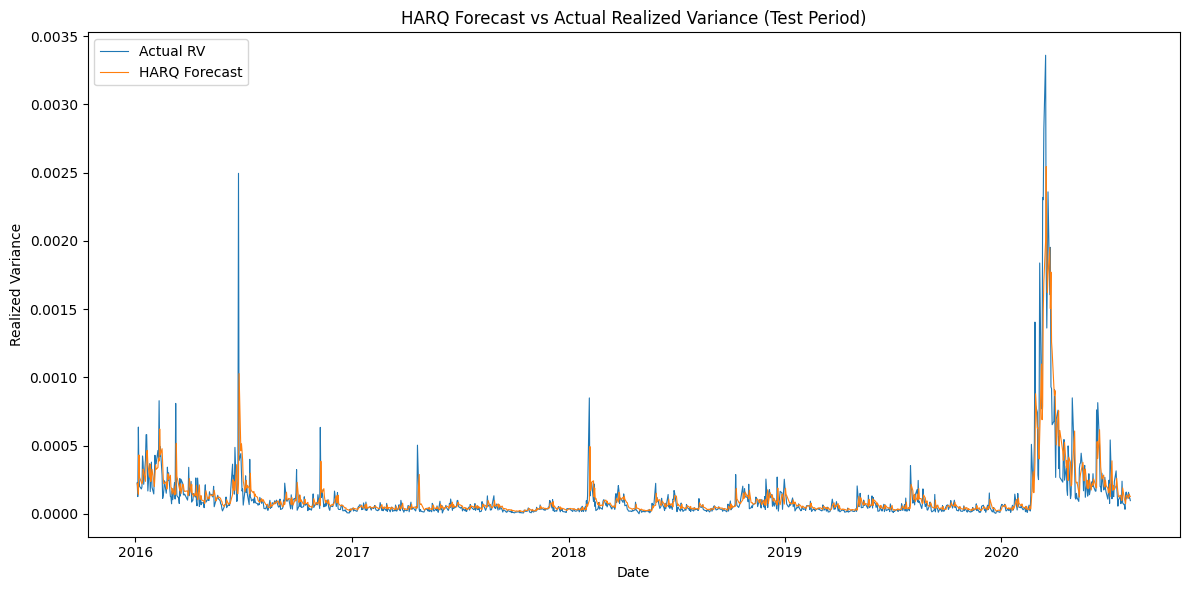

In [28]:
import matplotlib.pyplot as plt

df_plot = df_forecast_harQ.loc[df_test.index.min():df_test.index.max()].copy()

plt.figure(figsize=(12,6))
plt.plot(df_plot.index, df_plot["Actual"], label="Actual RV", linewidth=0.8)
plt.plot(df_plot.index, df_plot["Forecast"], label="HARQ Forecast", linewidth=0.8)

plt.title("HARQ Forecast vs Actual Realized Variance (Test Period)")
plt.xlabel("Date")
plt.ylabel("Realized Variance")
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
mean_train = df_train["RV_target"].mean()

df_forecast_val = df_forecast_harQ.loc[val_start:val_end]
df_forecast_test = df_forecast_harQ.loc[test_start:test_end]

# Validation
sse_val = np.sum((df_forecast_val["Actual"] - df_forecast_val["Forecast"])**2)
sse_val_bench = np.sum((df_forecast_val["Actual"] - mean_train)**2)
r2_oos_val = 1 - (sse_val / sse_val_bench)

# Test
sse_test = np.sum((df_forecast_test["Actual"] - df_forecast_test["Forecast"])**2)
sse_test_bench = np.sum((df_forecast_test["Actual"] - mean_train)**2)
r2_oos_test = 1 - (sse_test / sse_test_bench)

print("Out-of-sample R^2 (Validation, HARQ):", r2_oos_val)
print("Out-of-sample R^2 (Test, HARQ):", r2_oos_test)

Out-of-sample R^2 (Validation, HARQ): 0.38162310640626007
Out-of-sample R^2 (Test, HARQ): 0.672472523538749


* $R^2_{\text{OOS}} > 0$ --> model beats mean forecast
* $R^2_{\text{OOS}} = 0$ --> same as mean forecast
* $R^2_{\text{OOS}} < 0$ --> wore than mean forecast

## Performance during COVID

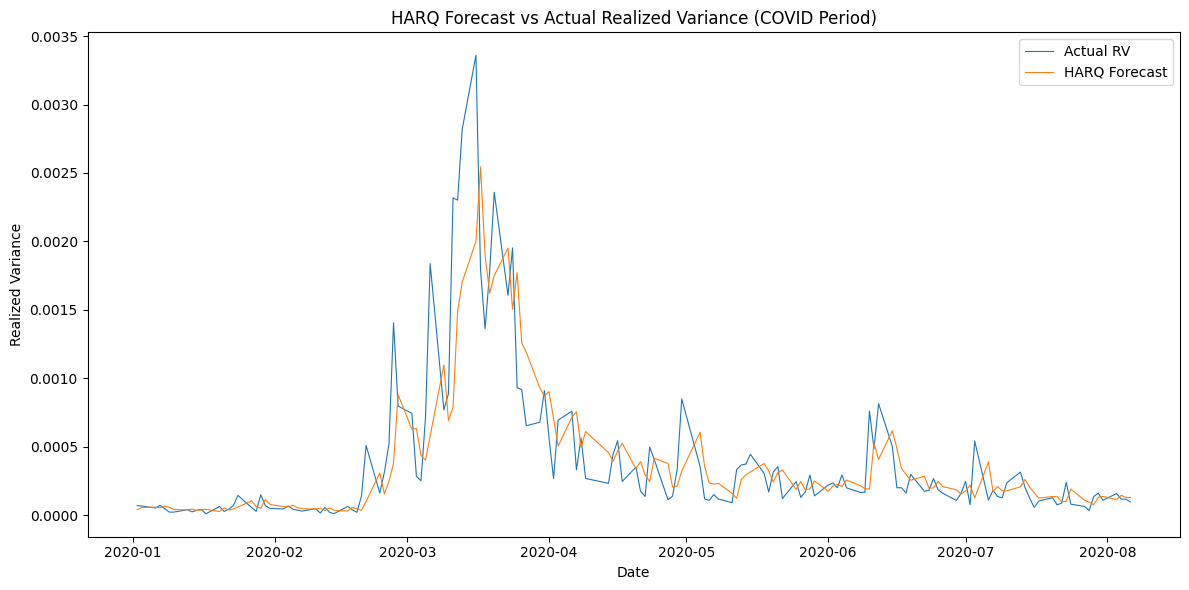

In [34]:
df_covid = df_forecast_harQ.loc["2020-01-01":].copy()

plt.figure(figsize=(12,6))
plt.plot(df_covid.index, df_covid["Actual"], label="Actual RV", linewidth=0.8)
plt.plot(df_covid.index, df_covid["Forecast"], label="HARQ Forecast", linewidth=0.8)

plt.title("HARQ Forecast vs Actual Realized Variance (COVID Period)")
plt.xlabel("Date")
plt.ylabel("Realized Variance")
plt.legend()
plt.tight_layout()
plt.show()